# Finding Maxima and Minima

**This notebook is self-contained; it recaps the first and second derivatives before using them.**

A great deal of applied mathematics is really one question: **what is the best setting?** The cheapest
route, the dose that works without harming, the model parameters that fit the data most closely. All
of them are *optimization* — finding where a function reaches its highest or lowest value.

Calculus answers this. At a peak or a valley the curve is momentarily flat, so the derivative is zero.
Finding those flat spots and then working out which is which is the whole method.

## Learning objectives

- Find **critical points** by solving $f'(x) = 0$.
- Classify each one using the **second-derivative test**.
- Distinguish a **local** extremum from a **global** one.

## Background

Recall $f'$ gives the slope and $f''$ gives the concavity (§3.3). At a peak or a valley the tangent
line is horizontal, so:

$$\textbf{Step 1 — find the critical points: } f'(x) = 0$$

A flat spot alone doesn't say *which* kind it is, so:

$$\textbf{Step 2 — classify with } f''$$

- $f''(x) < 0$ — concave down, a dome: **local maximum**.
- $f''(x) > 0$ — concave up, a bowl: **local minimum**.
- $f''(x) = 0$ — inconclusive; could be an inflection point.

Two cautions worth carrying:

- **Local is not global.** A function can have many valleys; the derivative test finds them all and
  cannot tell you which is deepest. You must compare.
- **The endpoints matter.** On a closed interval the true maximum may sit at an edge, where the
  derivative was never zero at all.

## This notebook covers

1. A function with several peaks and valleys.
2. Finding the critical points.
3. Classifying them with $f''$.
4. Local versus global.
5. When $f'(x) = 0$ can't be solved.

**Prerequisites:** `U3-3_Derivatives-3_SecondDerivativeAndConcavity`

**Dataset:** none — functions are entered directly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers
# plotting helper: draw x-y graphs like the usual coordinate plane
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

## 1. A function with several flat spots

Take

$$f(x) = x^4 - 8x^2 + 3x$$

By the power rule,

$$f'(x) = 4x^3 - 16x + 3, \qquad f''(x) = 12x^2 - 16$$

Looking at the plot, there are clearly two valleys and one peak. The derivative should be zero at all
three.

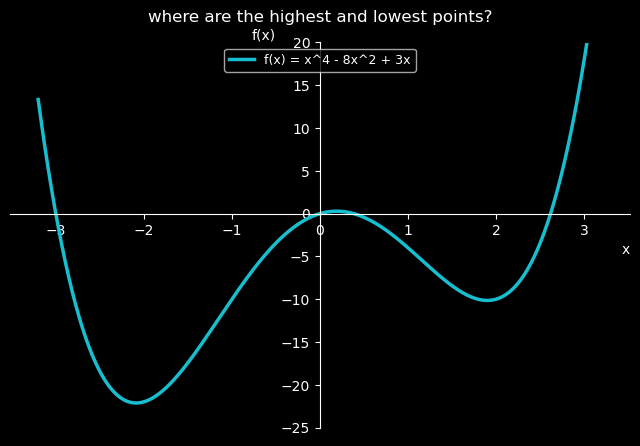

In [2]:
def f(x):
    return x**4 - 8*x**2 + 3*x

def df(x):
    return 4*x**3 - 16*x + 3

def d2f(x):
    return 12*x**2 - 16

xs = np.linspace(-3.2, 3.2, 500)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(xs, f(xs), color="tab:cyan", lw=2.5, label="f(x) = x^4 - 8x^2 + 3x")
center_axes(ax)
ax.set_xlabel("x", loc="right")
ax.set_ylabel("f(x)", loc="top", rotation=0)
ax.set_ylim(-25, 20)
ax.legend(loc="upper center", fontsize=9)
ax.set_title("where are the highest and lowest points?", pad=15)
plt.show()

## 2. Finding the critical points

Solve $f'(x) = 0$. This is a cubic, so rather than factor it by hand we let NumPy find the roots —
which is what you would do in practice anyway.

In [3]:
# f'(x) = 4x^3 - 16x + 3, written as coefficients from the highest power down
critical = np.roots([4, 0, -16, 3])
critical = np.sort(critical[np.isreal(critical)].real)

print("critical points, where f'(x) = 0:")
for c in critical:
    print(f"   x = {c:+.5f}    f'(x) = {df(c):+.1e}   (zero, as required)")

critical points, where f'(x) = 0:
   x = -2.08787    f'(x) = +3.6e-14   (zero, as required)
   x = +0.18919    f'(x) = -4.4e-16   (zero, as required)
   x = +1.89868    f'(x) = +0.0e+00   (zero, as required)


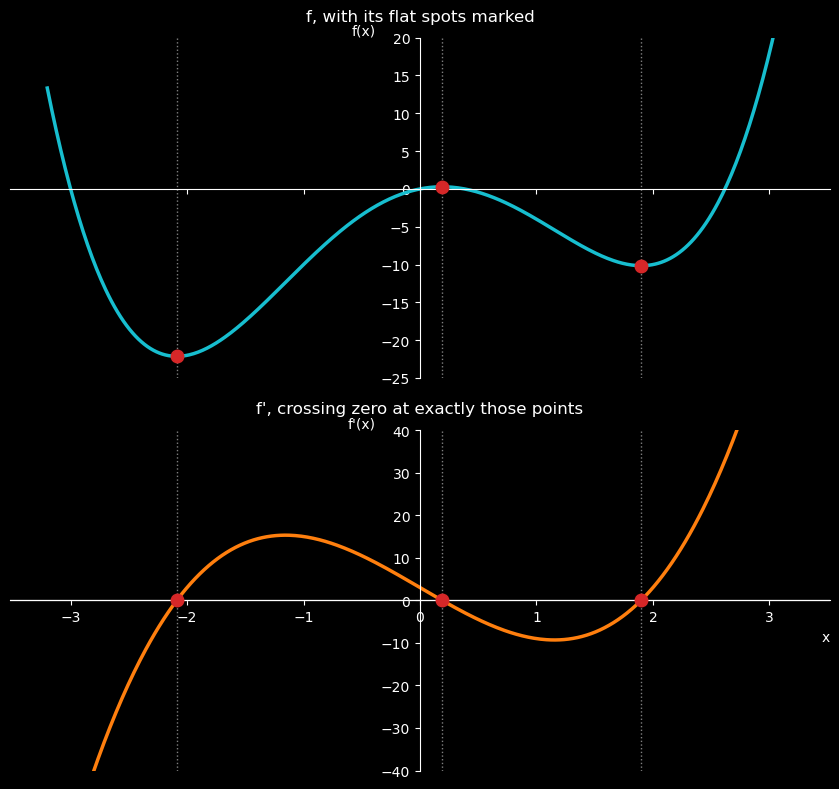

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(8.5, 8), sharex=True)

axes[0].plot(xs, f(xs), color="tab:cyan", lw=2.5)
axes[0].set_ylabel("f(x)", loc="top", rotation=0)
axes[0].set_ylim(-25, 20)
axes[0].set_title("f, with its flat spots marked", pad=12)

axes[1].plot(xs, df(xs), color="tab:orange", lw=2.5)
axes[1].axhline(0, color="gray", lw=1)
axes[1].set_ylabel("f'(x)", loc="top", rotation=0)
axes[1].set_xlabel("x", loc="right")
axes[1].set_ylim(-40, 40)
axes[1].set_title("f', crossing zero at exactly those points", pad=12)

for c in critical:
    axes[0].plot(c, f(c), "o", color="tab:red", markersize=9, zorder=5)
    axes[0].axvline(c, color="gray", ls=":", lw=1)
    axes[1].plot(c, 0, "o", color="tab:red", markersize=9, zorder=5)
    axes[1].axvline(c, color="gray", ls=":", lw=1)

for ax in axes:
    center_axes(ax)
plt.tight_layout()
plt.show()

## 3. Which is which?

Three flat spots — but is each a peak or a valley? Evaluate $f''$ at each one. Concave down means a
maximum; concave up means a minimum.

In [5]:
print(f"{'x':>10} {'f(x)':>10} {'f\u2032\u2032(x)':>10}   shape          type")
print("-" * 60)
kinds = []
for c in critical:
    second = d2f(c)
    if second < 0:
        shape, kind = "concave down", "local MAXIMUM"
    elif second > 0:
        shape, kind = "concave up  ", "local minimum"
    else:
        shape, kind = "flat        ", "inconclusive"
    kinds.append(kind)
    print(f"{c:10.4f} {f(c):10.4f} {second:10.4f}   {shape}   {kind}")

         x       f(x)     f′′(x)   shape          type
------------------------------------------------------------
   -2.0879   -22.1346    36.3106   concave up     local minimum
    0.1892     0.2825   -15.5705   concave down   local MAXIMUM
    1.8987   -10.1479    27.2599   concave up     local minimum


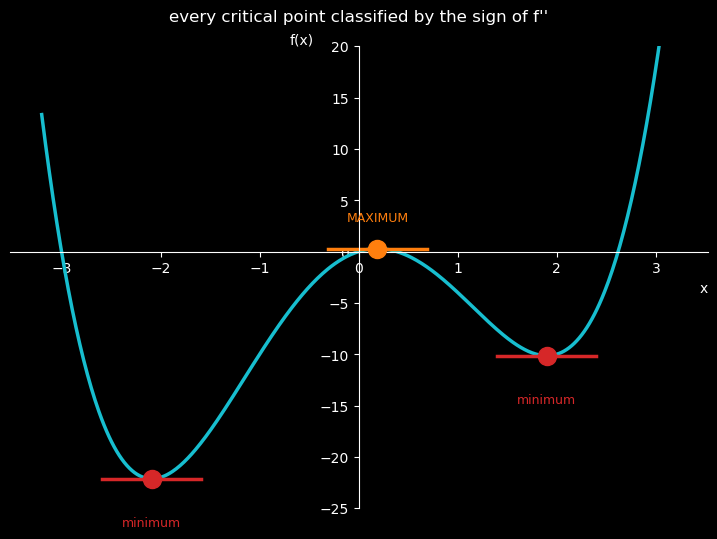

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(xs, f(xs), color="tab:cyan", lw=2.5)

for c, kind in zip(critical, kinds):
    color = "tab:orange" if "MAX" in kind else "tab:red"
    ax.plot(c, f(c), "o", color=color, markersize=13, zorder=5)
    # a short tangent line, to show it really is flat there
    seg = np.linspace(c - 0.5, c + 0.5, 10)
    ax.plot(seg, np.full_like(seg, f(c)), color=color, lw=2.5)
    ax.annotate(kind.replace("local ", ""), (c, f(c)), textcoords="offset points",
                xytext=(0, 20 if "MAX" in kind else -34), ha="center", color=color, fontsize=9)

center_axes(ax)
ax.set_xlabel("x", loc="right")
ax.set_ylabel("f(x)", loc="top", rotation=0)
ax.set_ylim(-25, 20)
ax.set_title("every critical point classified by the sign of f''", pad=18)
plt.show()

## 4. Local is not global

The derivative test found *three* extrema, but they are not equally important. Both valleys are local
minima — at each, the function is lower than everything nearby. Only one is the **global** minimum,
the lowest point overall.

There is no derivative test for this. You have to evaluate and compare. And in a problem you cannot
plot — say, twenty variables — you have no picture to fall back on, which is exactly why optimization
gets hard.

In [7]:
minima = [(c, f(c)) for c, k in zip(critical, kinds) if "minimum" in k]
deepest = min(minima, key=lambda p: p[1])

for c, v in minima:
    tag = "  <- GLOBAL minimum (the deepest)" if (c, v) == deepest else "  <- only a local minimum"
    print(f"local minimum at x = {c:+.4f}, f = {v:9.4f}{tag}")

print(f"\nThe two valleys differ by {abs(minima[0][1] - minima[1][1]):.3f}.")

local minimum at x = -2.0879, f =  -22.1346  <- GLOBAL minimum (the deepest)
local minimum at x = +1.8987, f =  -10.1479  <- only a local minimum

The two valleys differ by 11.987.


The gap between the two valleys is the whole problem. An algorithm that simply walks downhill from a bad starting point lands in the shallower one **and has no way to know** — from inside that valley, everything nearby really is higher.


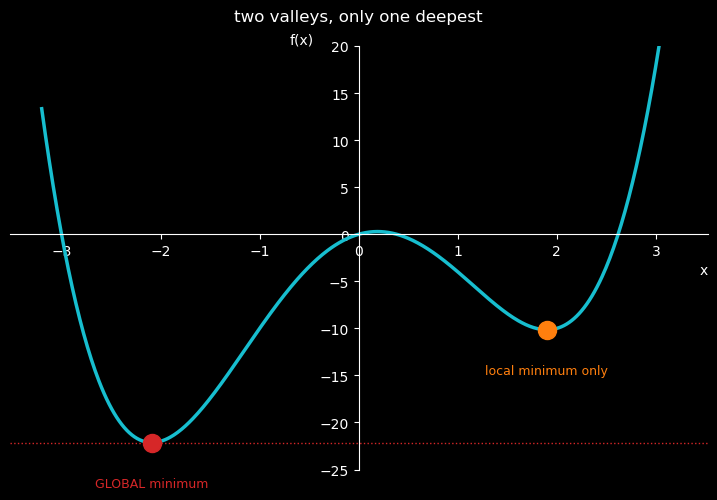

In [8]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(xs, f(xs), color="tab:cyan", lw=2.5)
for c, v in minima:
    is_global = (c, v) == deepest
    ax.plot(c, v, "o", color="tab:red" if is_global else "tab:orange", markersize=13, zorder=5)
    ax.annotate("GLOBAL minimum" if is_global else "local minimum only",
                (c, v), textcoords="offset points", xytext=(0, -32), ha="center",
                color="tab:red" if is_global else "tab:orange", fontsize=9)
ax.axhline(deepest[1], color="tab:red", ls=":", lw=1)

center_axes(ax)
ax.set_xlabel("x", loc="right")
ax.set_ylabel("f(x)", loc="top", rotation=0)
ax.set_ylim(-25, 20)
ax.set_title("two valleys, only one deepest", pad=18)
plt.show()

## 5. When you cannot solve $f'(x) = 0$

Everything above depended on being able to *solve* $f'(x) = 0$. For a polynomial that is fine. But
consider

$$f(x) = x^2 - 3\cos(10x)$$

Its derivative is

$$f'(x) = 2x + 30\sin(10x)$$

and setting that to zero gives $2x = -30\sin(10x)$ — an equation mixing a polynomial with a
trigonometric function, which **has no closed-form solution**. There is no rearranging that isolates
$x$. Worse, the plot shows this function has many local minima, not one.

This is the normal situation in practice, not an unlucky example. Real objective functions — the loss
of a machine-learning model, say — have thousands of variables and no solvable derivative at all.

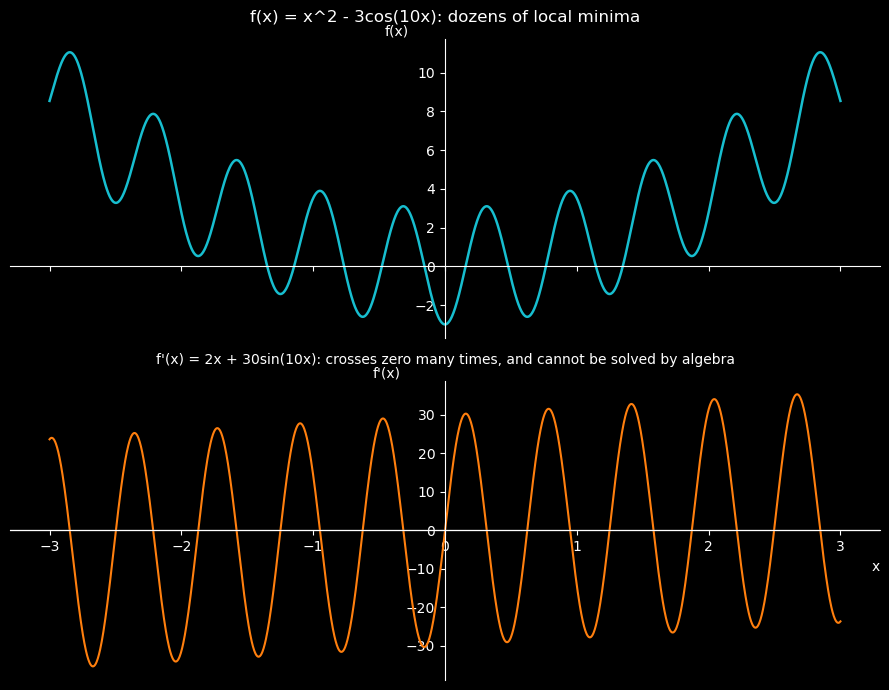

the derivative crosses zero about 19 times on this interval alone


In [9]:
def hard(x):
    return x**2 - 3*np.cos(10*x)

def dhard(x):
    return 2*x + 30*np.sin(10*x)

xs2 = np.linspace(-3, 3, 2000)

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
axes[0].plot(xs2, hard(xs2), color="tab:cyan", lw=1.8)
axes[0].set_ylabel("f(x)", loc="top", rotation=0)
axes[0].set_title("f(x) = x^2 - 3cos(10x): dozens of local minima", pad=12)

axes[1].plot(xs2, dhard(xs2), color="tab:orange", lw=1.5)
axes[1].axhline(0, color="gray", lw=1)
axes[1].set_ylabel("f'(x)", loc="top", rotation=0)
axes[1].set_xlabel("x", loc="right")
axes[1].set_title("f'(x) = 2x + 30sin(10x): crosses zero many times, and cannot be solved by algebra",
                  pad=12, fontsize=10)

for ax in axes:
    center_axes(ax)
plt.tight_layout()
plt.show()

crossings = np.sum(np.diff(np.sign(dhard(xs2))) != 0)
print(f"the derivative crosses zero about {crossings} times on this interval alone")

So we can *write down* $f'(x) = 0$, and we cannot *solve* it.

The way out is to stop solving and start **searching**: walk downhill from a starting guess and keep going until you stop improving. That is `U3-7_GradientDescent-1_Descent`, and it is how essentially every machine-learning model is trained.


## 6. Summary

- **Optimization** is finding where a function is largest or smallest, and calculus solves it by
  looking for flat spots.
- **Step 1:** critical points, where $f'(x) = 0$.
- **Step 2:** classify with the second derivative — $f'' < 0$ is a local **maximum**, $f'' > 0$ a local
  **minimum**, $f'' = 0$ inconclusive.
- **Local is not global.** The test finds every extremum and ranks none of them; you must compare
  values yourself.
- **Often $f'(x) = 0$ cannot be solved at all** — which is the normal case in practice and the reason
  the next section abandons solving in favour of searching.

Next: functions of more than one variable, and the derivative that generalizes to them
(`U3-6_Multivariable-1_Surface3D`).